In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# df = pd.read_csv(
#     "/workspaces/Effector-Structure-Prediction/04_results_tsv/pdb_metadata_with_tmalign_AF3.tsv",
#     sep="\t"
# )

# df.columns = df.columns.str.strip()

In [2]:
df = pd.read_excel(
    "/workspaces/Effector-Structure-Prediction/80_fungal_effector_structures_V9.xlsx", sheet_name="Structures", skiprows=5
)

df.columns = df.columns.str.strip()

In [3]:
print(df.columns.tolist())

['Structural family (inferred from La Naour Vernet et al. (2025))', 'PDB_ID', 'How many protein identities in crystal structure', 'Chain', 'PDB_ID_2', 'Annotation', 'Organism', 'Effector', 'Method', 'Resolution', 'Found in', 'Resolved by', 'Deposition_date', 'TM_score_crystal', 'TM_score_predicted', 'RMSD', 'Aligned_length', 'Seq_ID', 'Predicted_length', 'Experimental_length', 'Coverage', 'TM_score_crystal3', 'TM_score_predicted4', 'RMSD5', 'Aligned_length6', 'Seq_ID7', 'Predicted_length8', 'Experimental_length9', 'Coverage2', 'TM_score_crystal2', 'TM_score_predicted3', 'RMSD4', 'Aligned_length5', 'Seq_ID6', 'Predicted_length7', 'Experimental_length8', 'Coverage3']


In [ ]:
"""
All the graphs that I want to create:
    print([
    f"TM_score_crystal_{model}",
    f"TM_score_pred_{model}",
    f"RMSD_{model}",
    f"Aligned_length_{model}",
    f"Seq_ID_{model}",
    f"Fold_length_{model}",
    f"Experimental_length_{model}",
    f"Coverage_{model}",
    f"Runtime_seconds if available",
    ])

Each individual:
Box and whisker plot with TM_score_crystal, standard deviation as error bars 
Box and whisker plot with TM_score_pred, standard deviation as error bars 

Histogram of TM_score_crystal 
Histogram of RMSD

Combinations ESM vs AF3:
TM_score_crystal ESM against TM_score_crystal AF3

Continuous: Colored with aligned length, seq_ID, coverage, runtime_seconds, deposition date, resolution, proteins
Categorical: structural family, organism, method, 

Structural families: 
['AvrSr35-like', 'FOLD', 'KP4-like', 'LARS', 'MAX', 'RALPH', 'ToxA-like', 'Other']

Organisms:
Pyricularia oryzae = Magnaporthe oryzae
['Blumeria hordei', 'Fusarium oxysporum', 'Magnaporthe oryzae', 'Puccinia graminis', 'Pyrenophora tritici-repentis', 'Pyricularia oryzae', 'Other']

Method:
['Solution NMR', 'X-ray', 'Electron microscopy', 'Other']
"""

In [ ]:
df = df.rename(columns={
    "TM_score_predicted": "TM_score_ESM",
    "TM_score_predicted4": "TM_score_AF2",
    "TM_score_predicted3": "TM_score_AF3",
    "TM_score_crystal": "TM_score_crystal_ESM",
    "TM_score_crystal3": "TM_score_crystal_AF2",
    "TM_score_crystal2": "TM_score_crystal_AF3",
    "Predicted_length": "Length_ESM",
    "Predicted_length8": "Length_AF2",
    "Predicted_length7": "Length_AF3",
    "Coverage": "Coverage_ESM",
    "Coverage2": "Coverage_AF2",
    "Coverage3": "Coverage_AF3",
})

comparisons = [
    ("TM_score_ESM", "TM_score_AF2", "ESM vs AF2"),
    ("TM_score_ESM", "TM_score_AF3", "ESM vs AF3"),
    ("TM_score_AF2", "TM_score_AF3", "AF2 vs AF3"),
]

metadata = [
    "Structural family (inferred from La Naour Vernet et al. (2025))",
    "Organism",
    "Annotation",
    "Resolution",
    "Method",
    "Coverage_ESM",
    "Coverage_AF2",
    "Coverage_AF3",
    "Effector",
]

In [10]:
# Simplify the families
def simplify_family(family):

    if family in [
        "AvrSr35-like",
        "AvrSr35-like "
    ]:
        return "AvrSr35-like"

    elif family in [
        "FOLD",
        "FOLD "
    ]:
        return "FOLD"

    elif family in [
        "KP4-like", 
        "KP4-like "
    ]:
        return "KP4-like"

    elif family in [
        "LARS", "LARS "
    ]:
        return "LARS"

    elif family in [
        "MAX", "MAX "
    ]:
        return "MAX"

    elif family in [
        "RALPH", "RALPH "
    ]:
        return "RALPH"

    elif family in [
        "ToxA-like", "ToxA-like "
    ]:
        return "ToxA-like"

    else:
        return "Other"

df["Structural_family_simplified"] = df[
    "Structural family (inferred from La Naour Vernet et al. (2025))"
].apply(simplify_family)

print(df["Structural_family_simplified"].value_counts())

Structural_family_simplified
Other           29
MAX             26
RALPH            7
ToxA-like        6
LARS             4
AvrSr35-like     4
FOLD             3
KP4-like         2
Name: count, dtype: int64


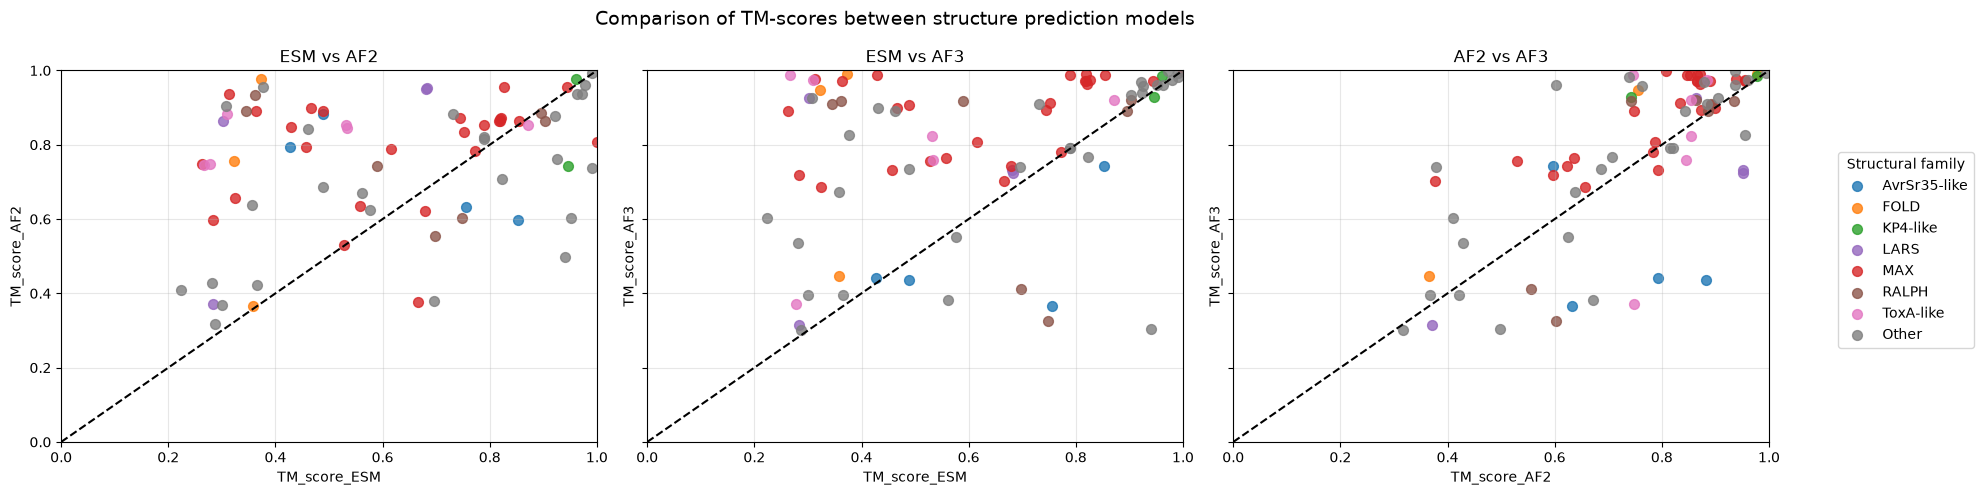

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the order of structural families
family_order = [
    'AvrSr35-like',
    'FOLD',
    'KP4-like',
    'LARS',
    'MAX',
    'RALPH',
    'ToxA-like',
    'Other'
]

# Colour mapping
family_colors = {
    'AvrSr35-like': 'tab:blue',
    'FOLD': 'tab:orange',
    'KP4-like': 'tab:green',
    'LARS': 'tab:purple',
    'MAX': 'tab:red',
    'RALPH': 'tab:brown',
    'ToxA-like': 'tab:pink',
    'Other': 'tab:gray'
}

comparisons = [
    ("TM_score_ESM", "TM_score_AF2", "ESM vs AF2"),
    ("TM_score_ESM", "TM_score_AF3", "ESM vs AF3"),
    ("TM_score_AF2", "TM_score_AF3", "AF2 vs AF3"),
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)


for ax, (xcol, ycol, title) in zip(axes, comparisons):

    for family in family_order:

        subset = df[
            df["Structural_family_simplified"] == family
        ]

        ax.scatter(
            subset[xcol],
            subset[ycol],
            label=family,
            color=family_colors[family],
            s=50,
            alpha=0.8
        )

    # perfect agreement line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_title(title)

    ax.grid(alpha=0.3)


# one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Structural family",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Comparison of TM-scores between structure prediction models",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [13]:
def simplify_organism(org):

    org = str(org).lower()

    if "blumeria hordei" in org:
        return "Blumeria hordei"

    elif "fusarium oxysporum" in org:
        return "Fusarium oxysporum"

    elif "magnaporthe oryzae" in org:
        return "Magnaporthe oryzae"

    elif "pyricularia oryzae" in org:
        return "Magnaporthe oryzae"

    elif "puccinia graminis" in org:
        return "Puccinia graminis"

    elif "pyrenophora tritici-repentis" in org:
        return "Pyrenophora tritici-repentis"

    else:
        return "Other"


df["Organism_simplified"] = df["Organism"].apply(simplify_organism)
print(df["Organism_simplified"].value_counts())

Organism_simplified
Other                           33
Magnaporthe oryzae              26
Fusarium oxysporum               8
Puccinia graminis                6
Pyrenophora tritici-repentis     4
Blumeria hordei                  4
Name: count, dtype: int64


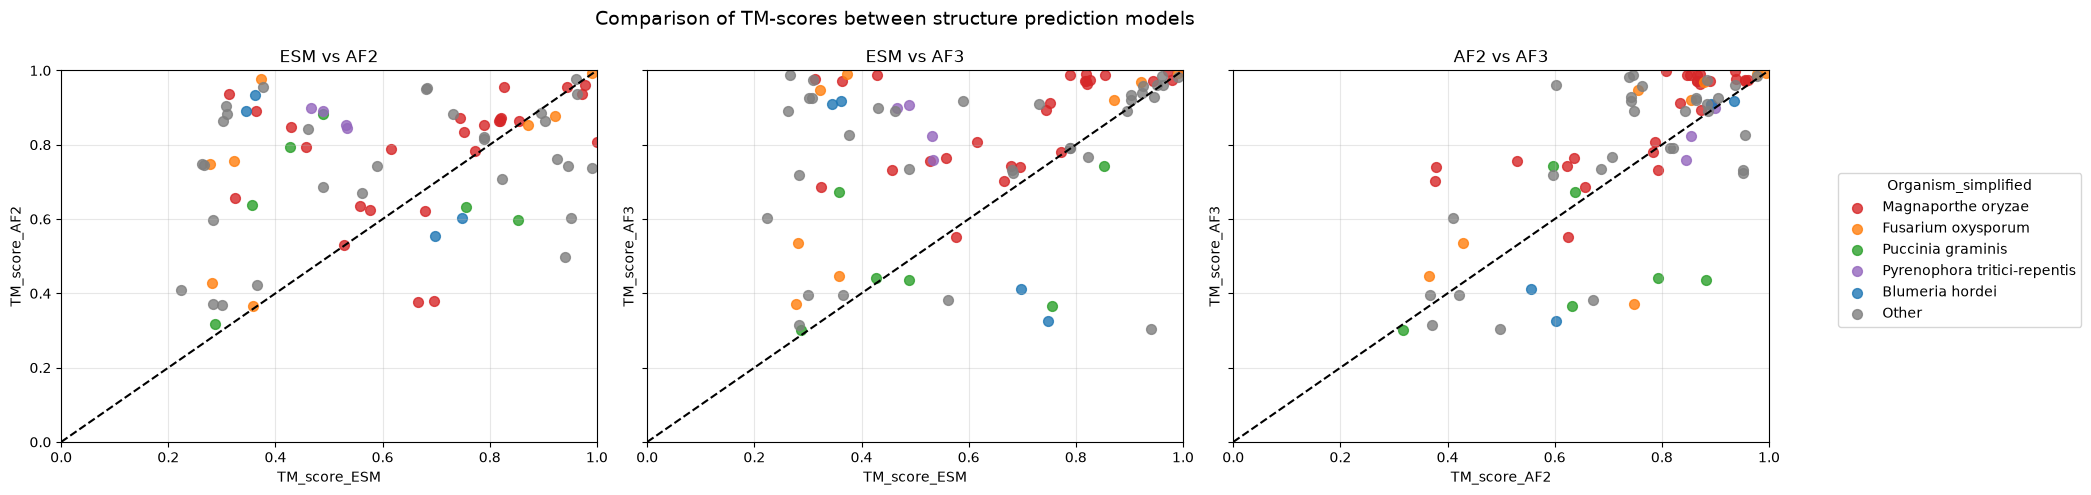

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Define the order of structural families
family_order = [
    'Magnaporthe oryzae',
    'Fusarium oxysporum',
    'Puccinia graminis',
    'Pyrenophora tritici-repentis',
    'Blumeria hordei',
    'Other'
]

# Colour mapping
family_colors = {
    'Other': 'tab:gray',
    'Magnaporthe oryzae': 'tab:red',
    'Fusarium oxysporum':'tab:orange',
    'Puccinia graminis':'tab:green',
    'Pyrenophora tritici-repentis':'tab:purple',
    'Blumeria hordei':'tab:blue'
}

comparisons = [
    ("TM_score_ESM", "TM_score_AF2", "ESM vs AF2"),
    ("TM_score_ESM", "TM_score_AF3", "ESM vs AF3"),
    ("TM_score_AF2", "TM_score_AF3", "AF2 vs AF3"),
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)


for ax, (xcol, ycol, title) in zip(axes, comparisons):

    for family in family_order:

        subset = df[
            df["Organism_simplified"] == family
        ]

        ax.scatter(
            subset[xcol],
            subset[ycol],
            label=family,
            color=family_colors[family],
            s=50,
            alpha=0.8
        )

    # perfect agreement line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_title(title)

    ax.grid(alpha=0.3)


# one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Organism_simplified",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Comparison of TM-scores between structure prediction models",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [16]:
def simplify_method(method):

    method = str(method).lower()

    if "nmr" in method:
        return "Solution NMR"

    elif "x-ray" in method or "xray" in method:
        return "X-ray"

    elif "electron" in method or "em" in method:
        return "Electron microscopy"

    else:
        return "Other"

df["Method_simplified"] = df["Method"].apply(simplify_method)
print(df["Method_simplified"].value_counts())

Method_simplified
X-ray                  59
Solution NMR           16
Electron microscopy     4
Other                   2
Name: count, dtype: int64


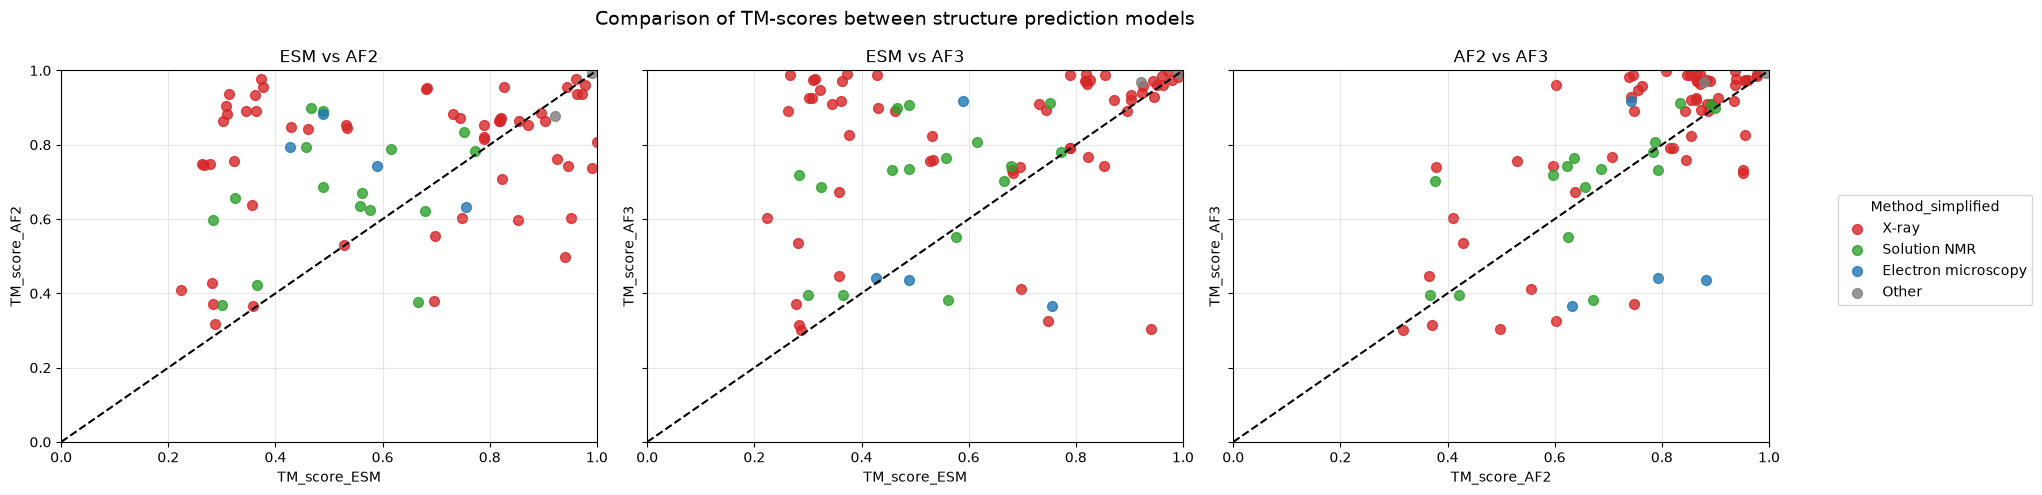

In [20]:
# Define the order of structural families
family_order = [
    'X-ray',
    'Solution NMR',
    'Electron microscopy',
    'Other',
]

# Colour mapping
family_colors = {
    'X-ray': 'tab:red',
    'Solution NMR':'tab:green',
    'Electron microscopy':'tab:blue',
    'Other' :'tab:gray',
}

comparisons = [
    ("TM_score_ESM", "TM_score_AF2", "ESM vs AF2"),
    ("TM_score_ESM", "TM_score_AF3", "ESM vs AF3"),
    ("TM_score_AF2", "TM_score_AF3", "AF2 vs AF3"),
]


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    sharex=True,
    sharey=True
)


for ax, (xcol, ycol, title) in zip(axes, comparisons):

    for family in family_order:

        subset = df[
            df["Method_simplified"] == family
        ]

        ax.scatter(
            subset[xcol],
            subset[ycol],
            label=family,
            color=family_colors[family],
            s=50,
            alpha=0.8
        )

    # perfect agreement line
    ax.plot(
        [0, 1],
        [0, 1],
        "--",
        color="black"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    ax.set_title(title)

    ax.grid(alpha=0.3)


# one shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Method_simplified",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

fig.suptitle(
    "Comparison of TM-scores between structure prediction models",
    fontsize=14
)

plt.tight_layout()
plt.show()

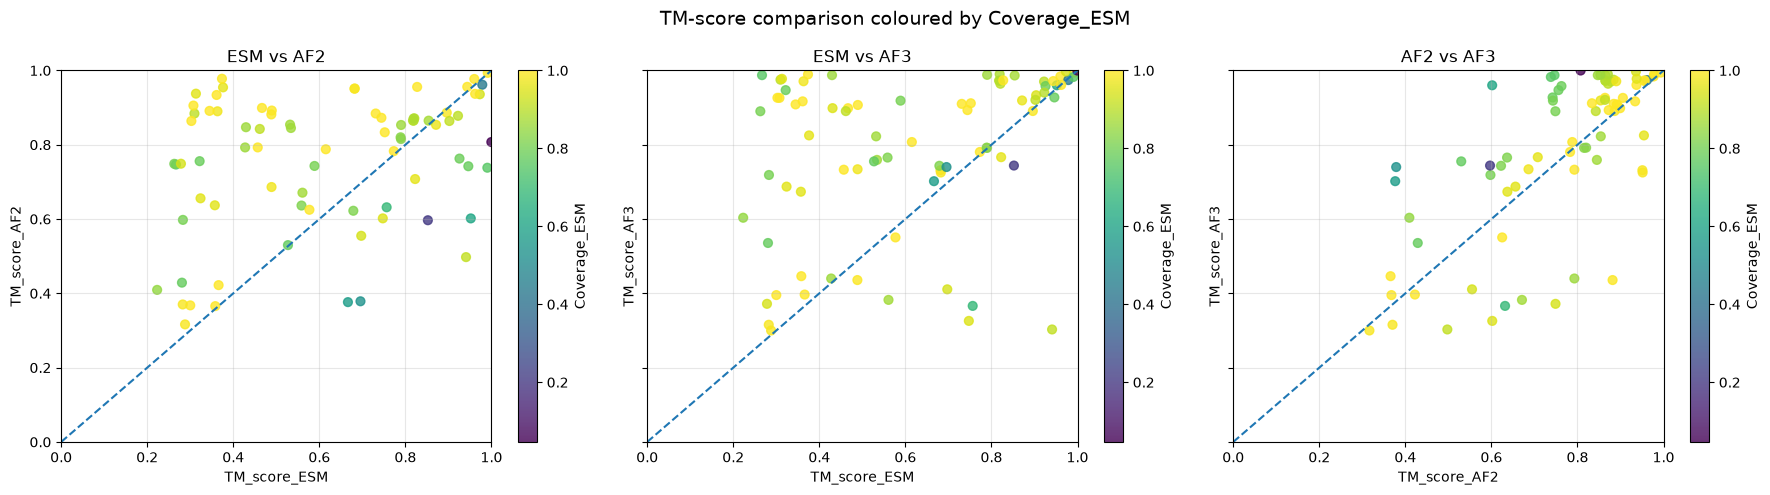

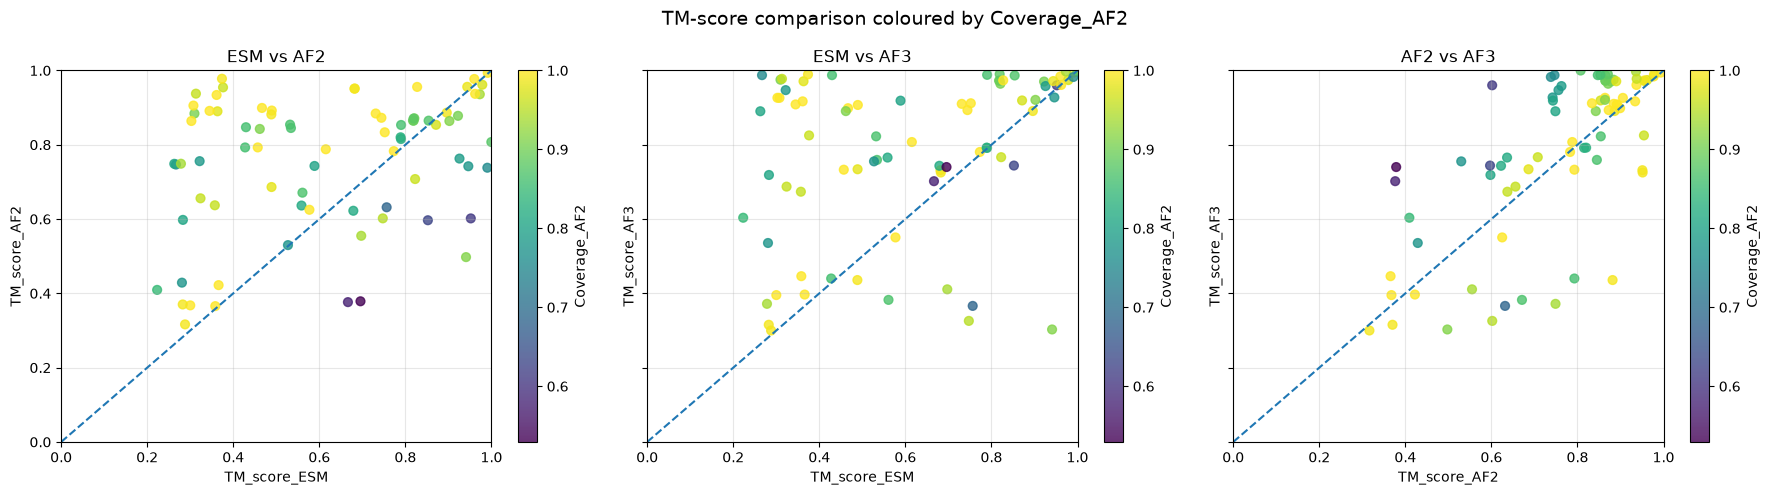

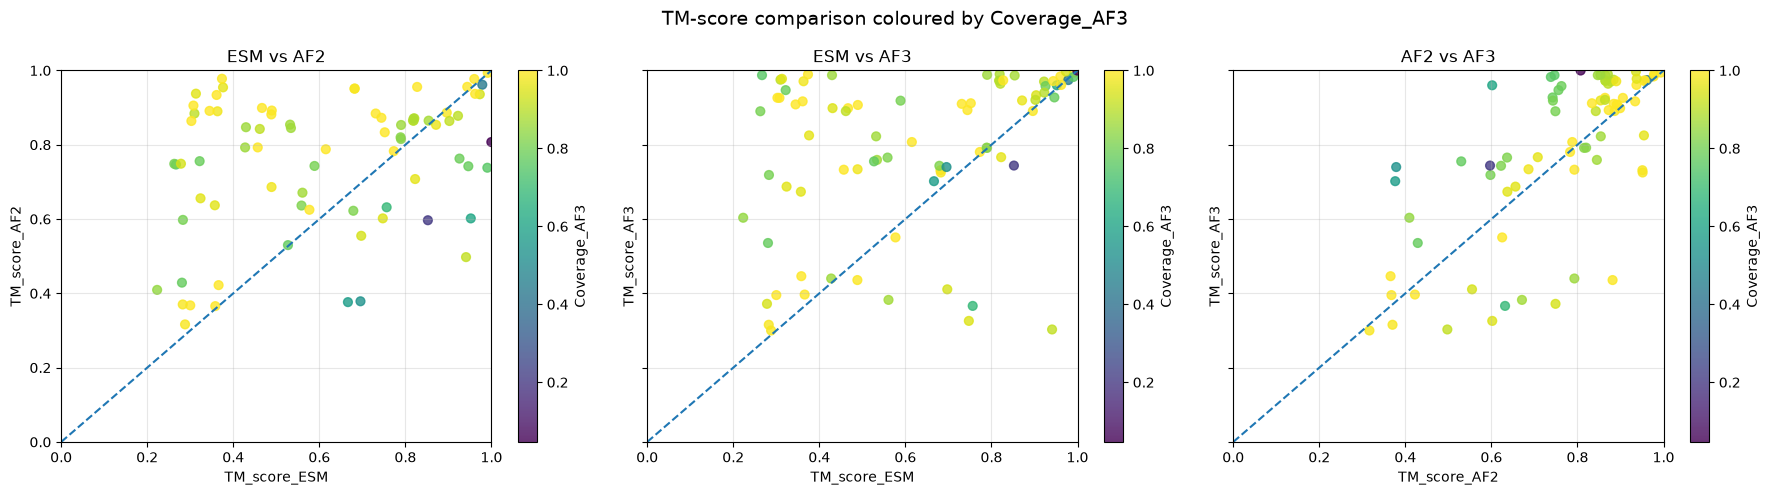

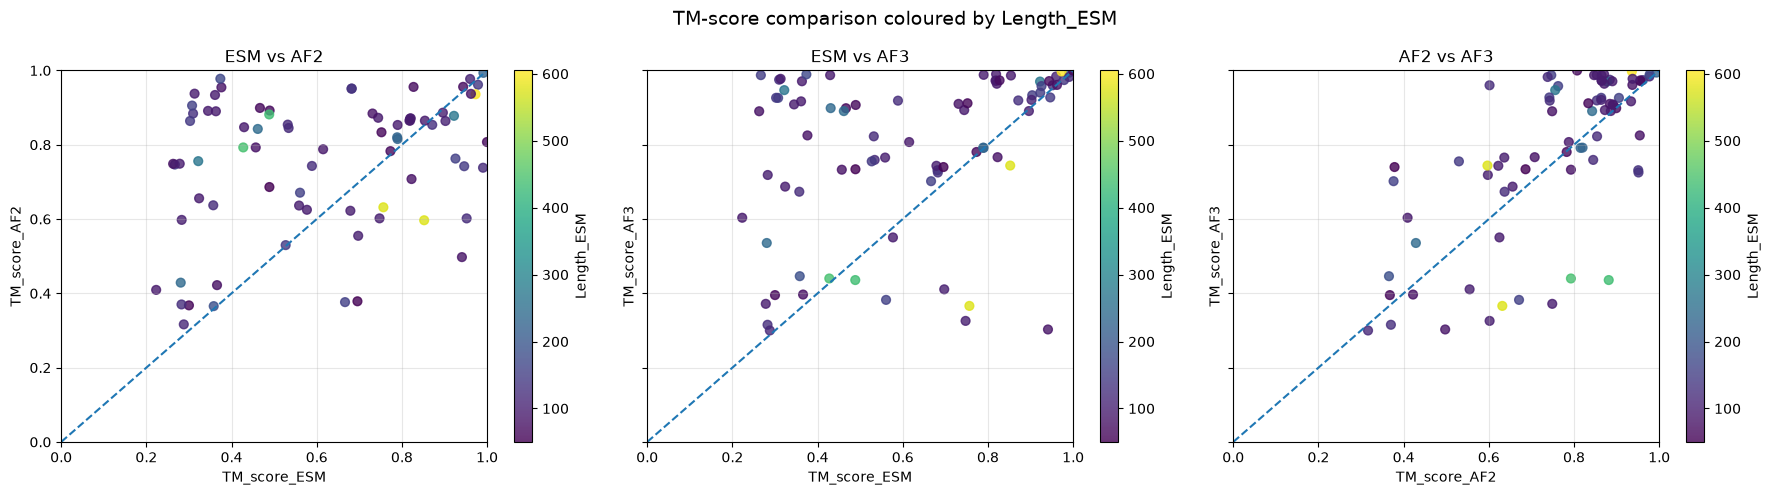

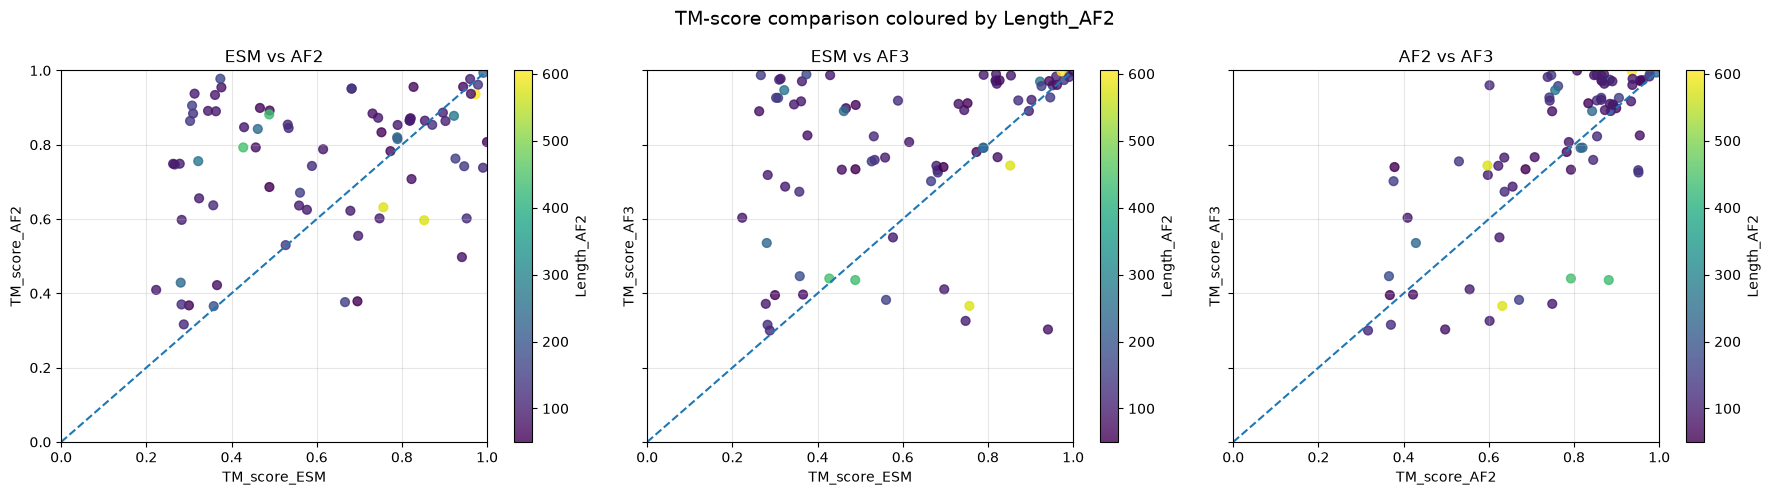

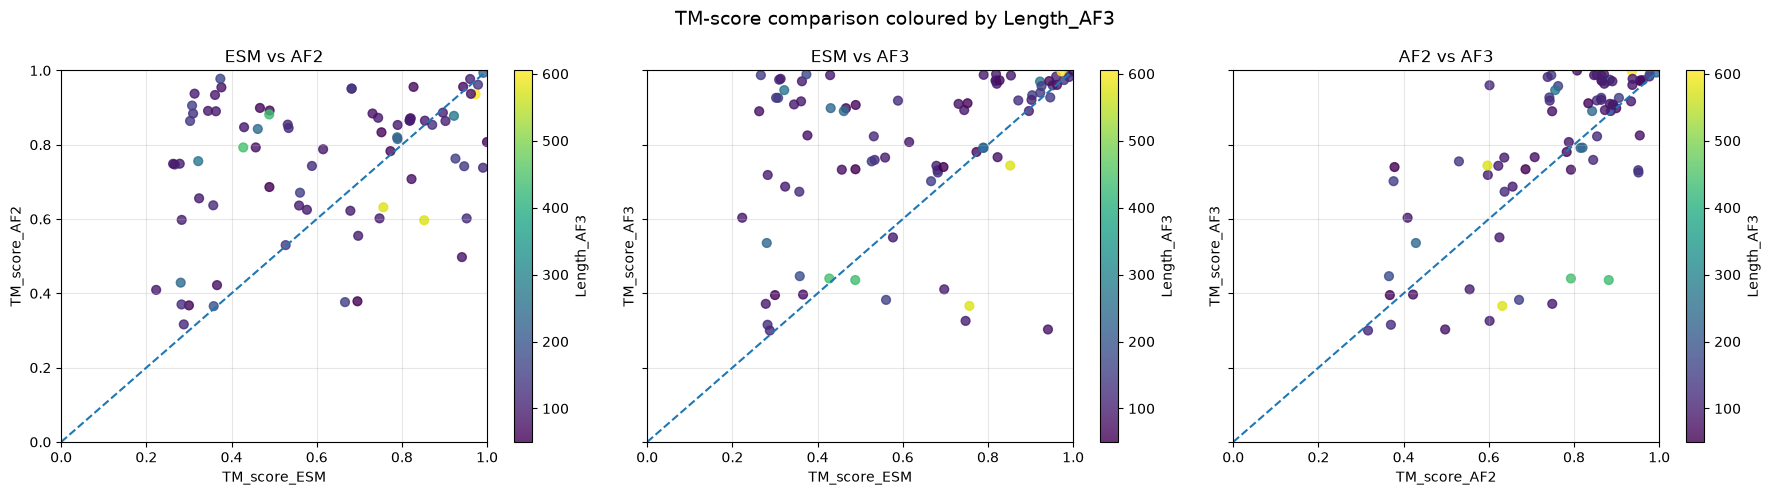

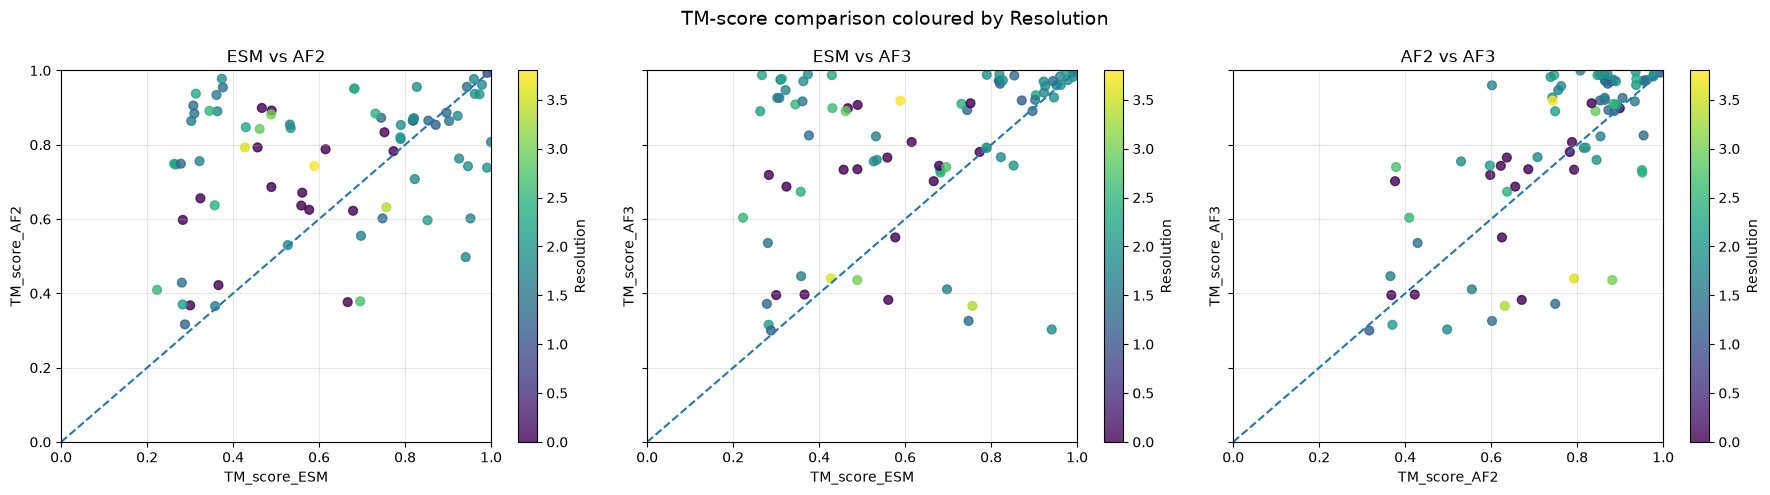

In [24]:
continuous_metadata = [
    "Coverage_ESM",
    "Coverage_AF2",
    "Coverage_AF3",
    "Length_ESM",
    "Length_AF2",
    "Length_AF3",
    "Resolution"
]

comparisons = [
    ("TM_score_ESM", "TM_score_AF2", "ESM vs AF2"),
    ("TM_score_ESM", "TM_score_AF3", "ESM vs AF3"),
    ("TM_score_AF2", "TM_score_AF3", "AF2 vs AF3"),
]


for colour_column in continuous_metadata:

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5),
        sharex=True,
        sharey=True
    )

    for ax, (xcol, ycol, title) in zip(axes, comparisons):

        scatter = ax.scatter(
            df[xcol],
            df[ycol],
            c=df[colour_column],
            s=40,
            alpha=0.8
        )

        cbar = plt.colorbar(
            scatter,
            ax=ax
        )

        cbar.set_label(colour_column)

        # diagonal = equal performance
        ax.plot(
            [0, 1],
            [0, 1],
            "--"
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xlabel(xcol)
        ax.set_ylabel(ycol)

        ax.set_title(title)

        ax.grid(alpha=0.3)

    fig.suptitle(
        f"TM-score comparison coloured by {colour_column}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()
    plt.close()

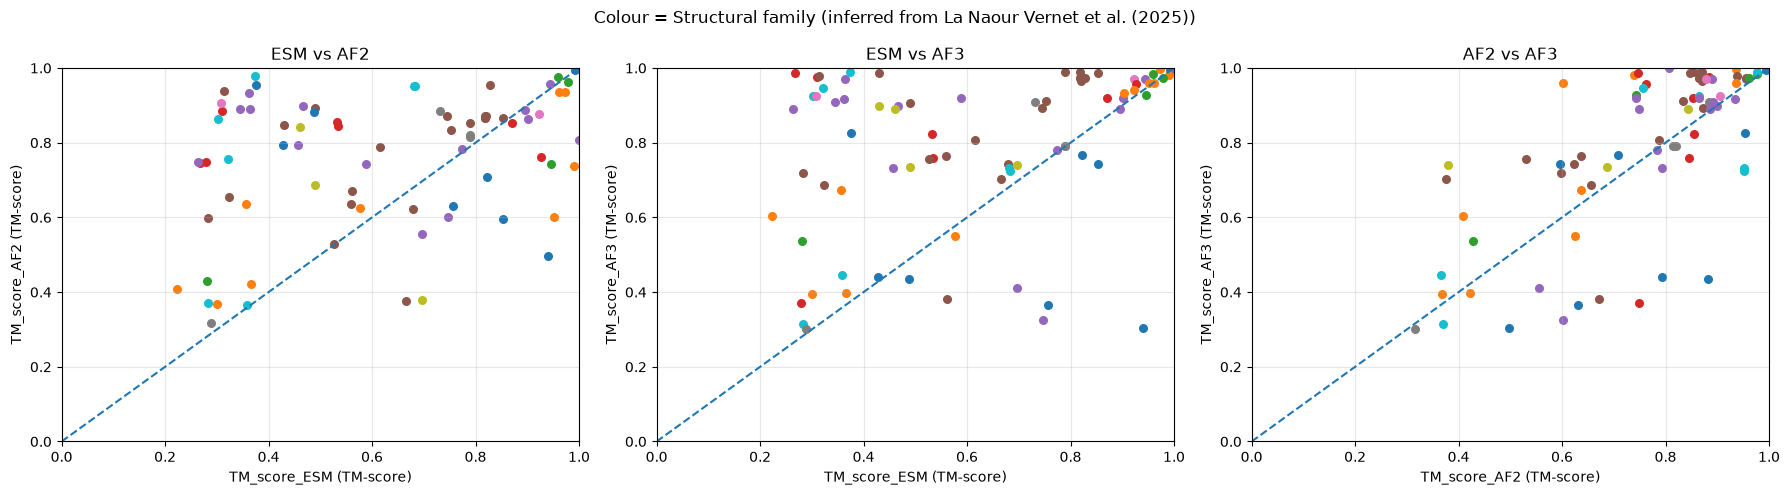

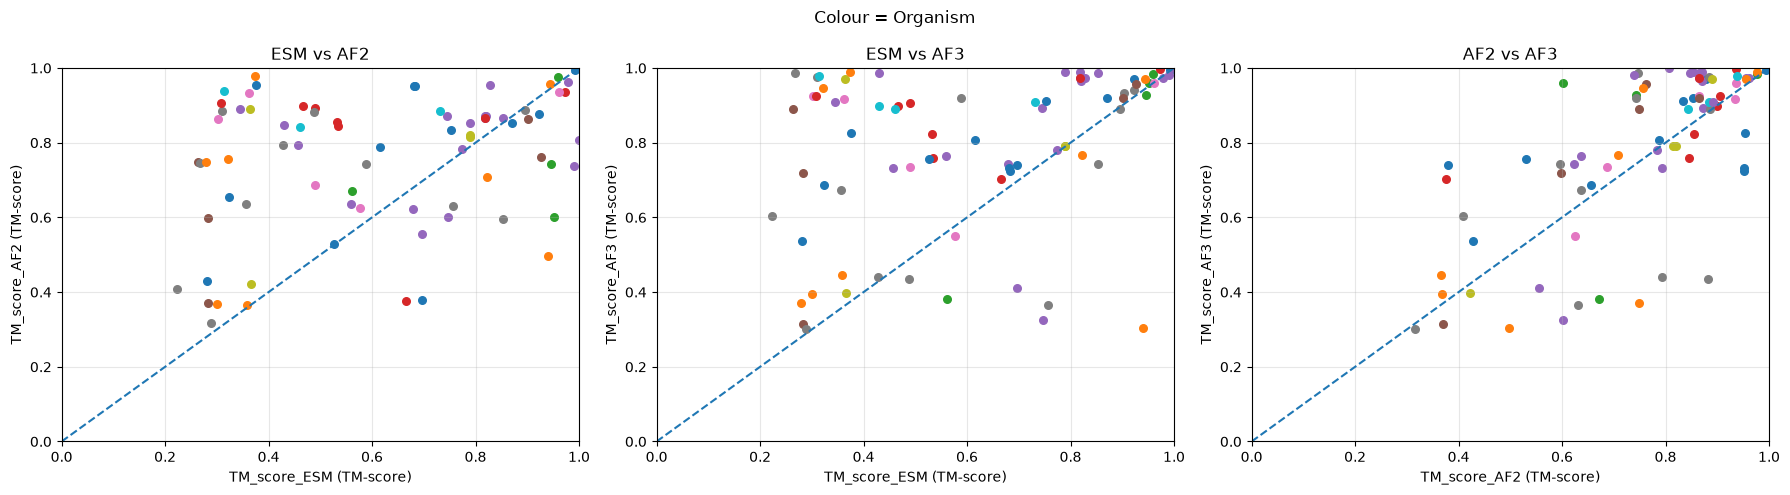

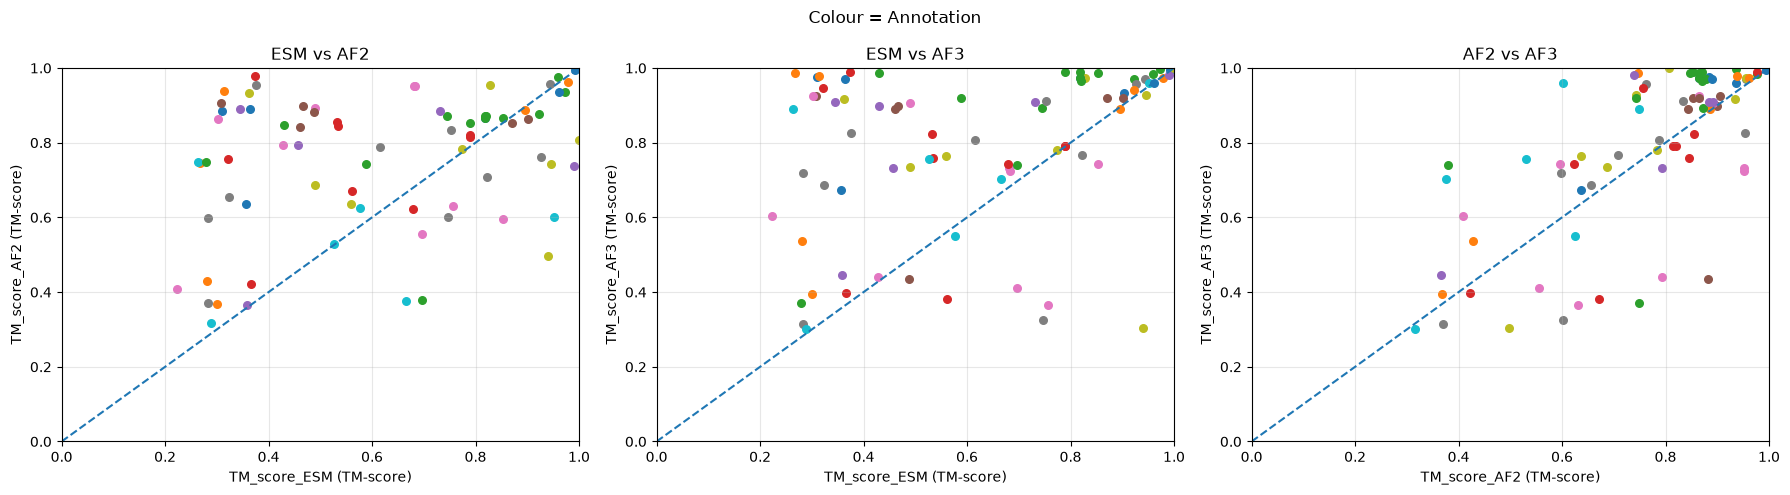

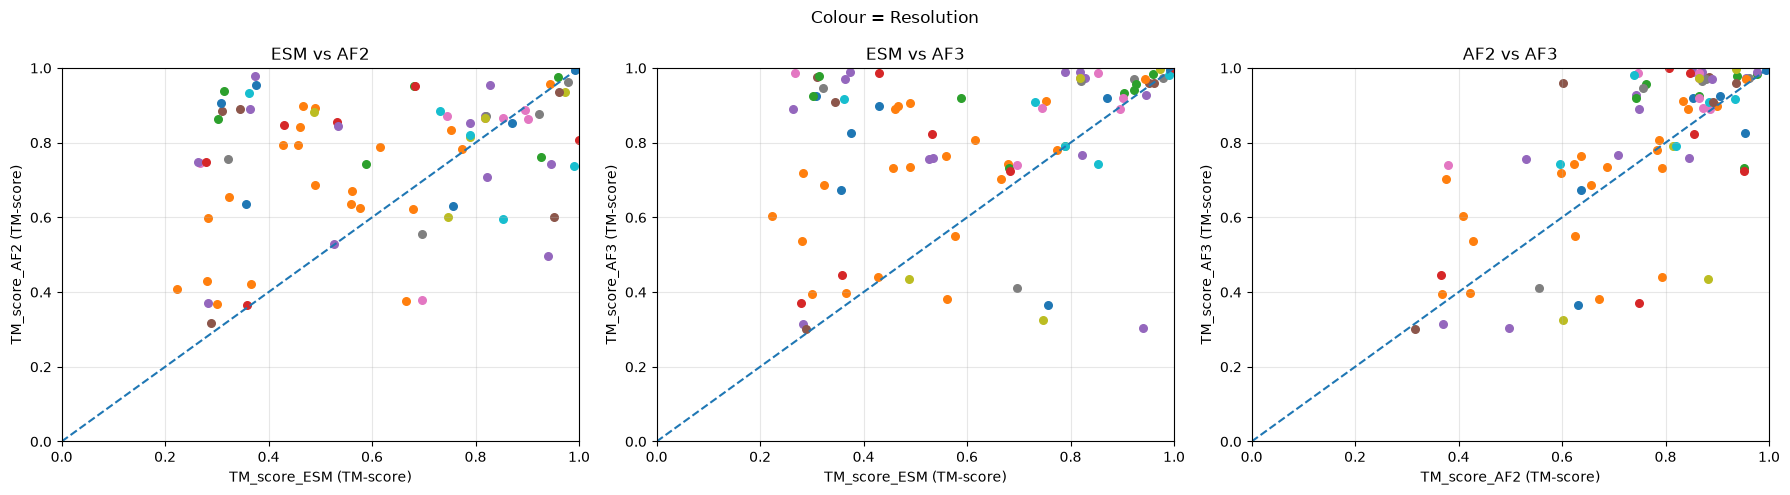

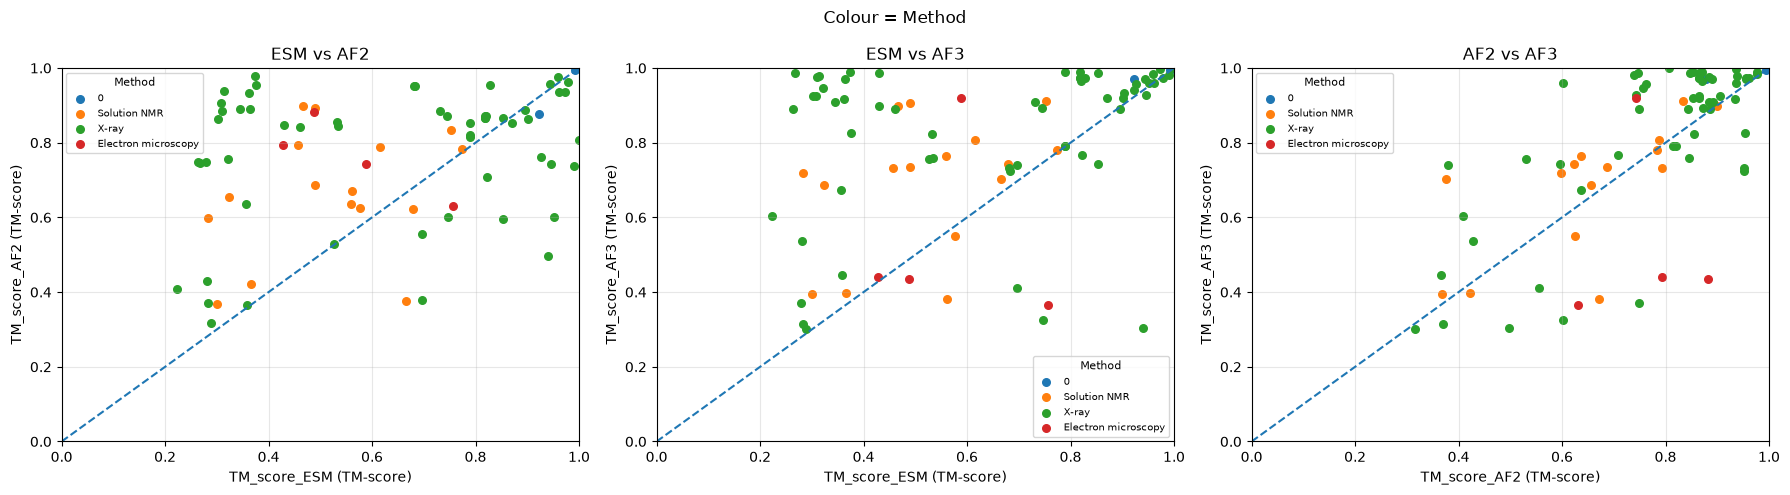

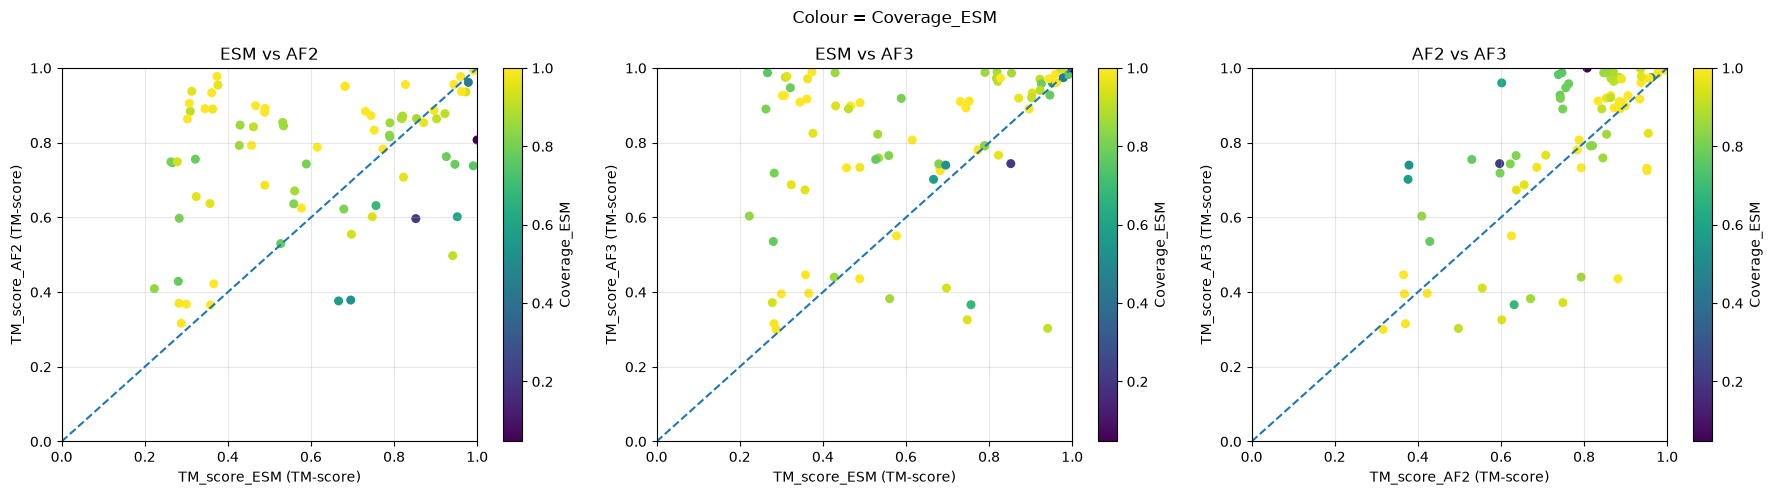

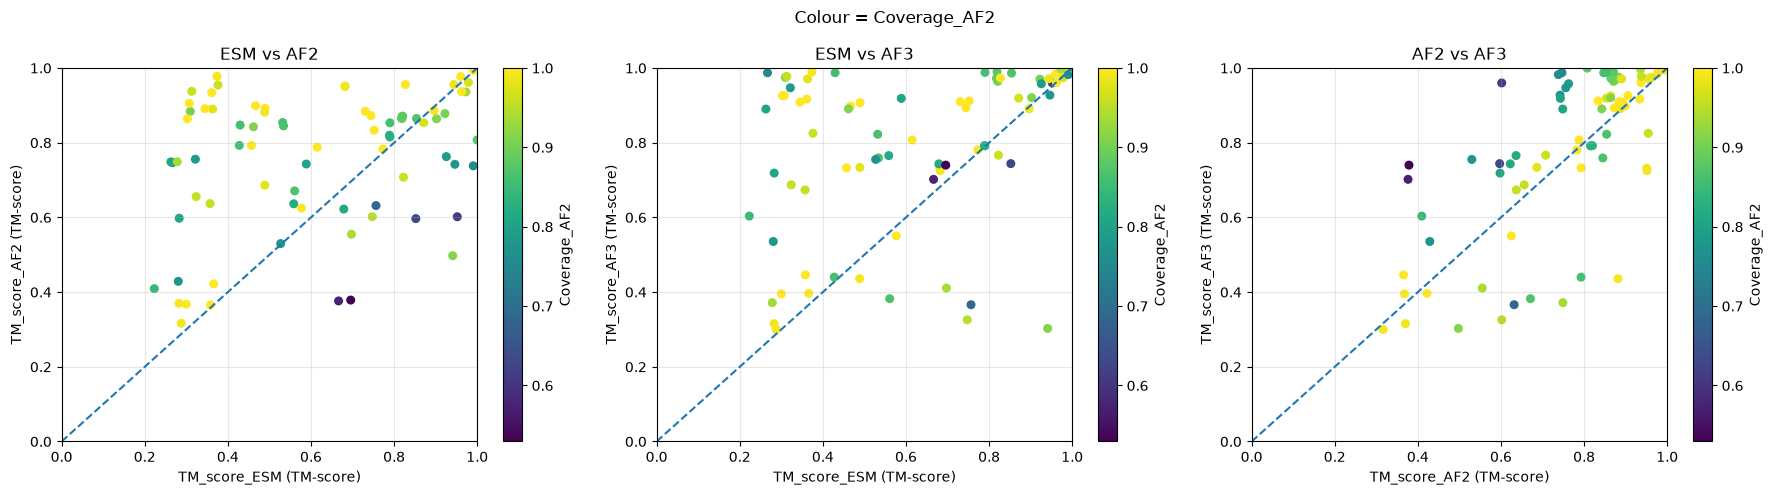

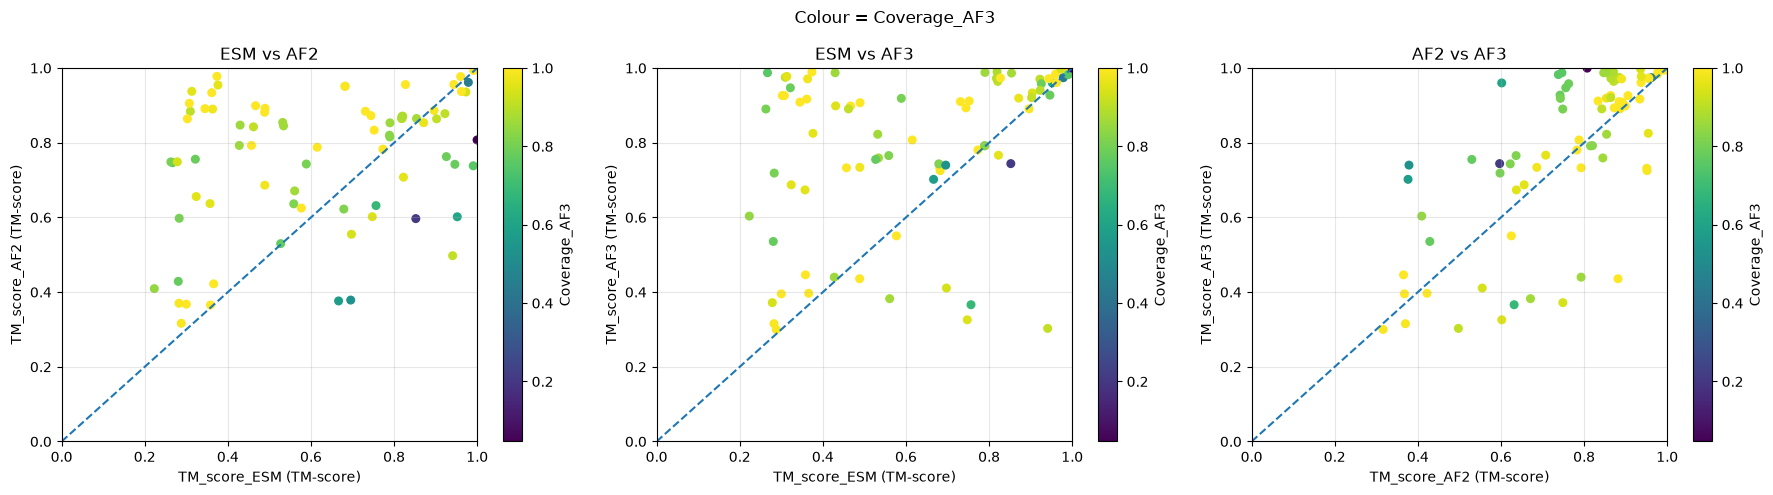

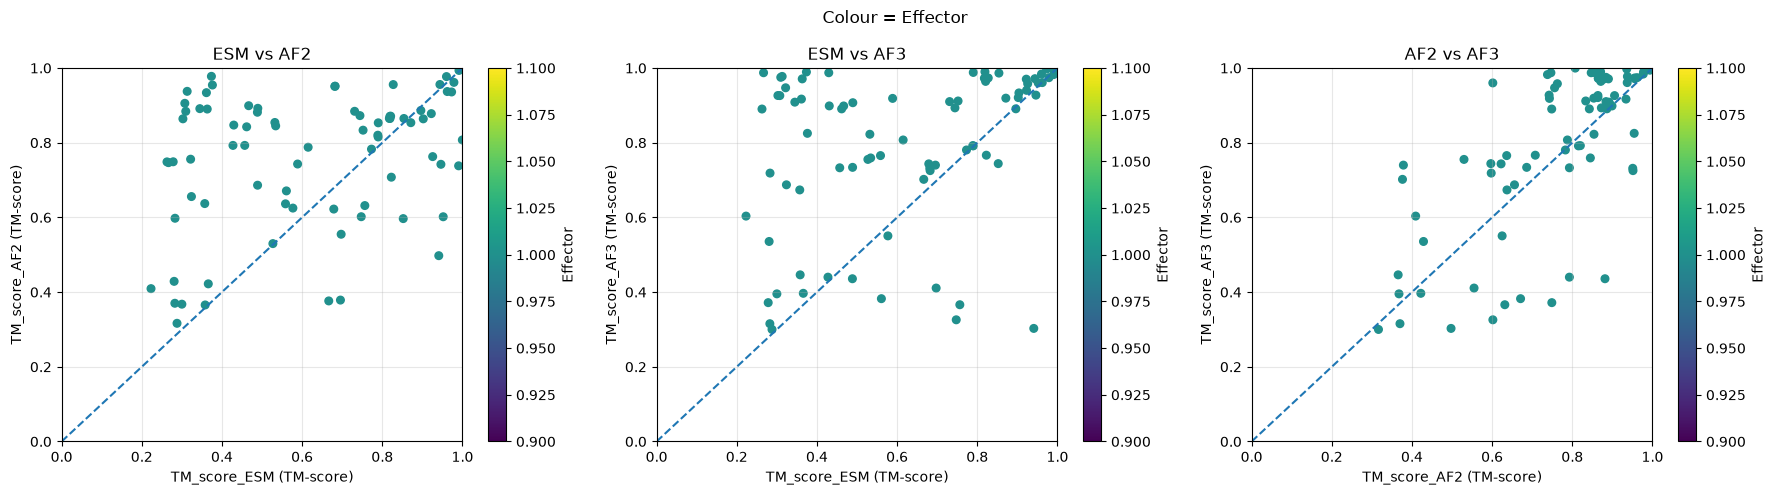

In [23]:
for colour_column in metadata:

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (xcol, ycol, title) in zip(axes, comparisons):

        if pd.api.types.is_numeric_dtype(df[colour_column]):

            scatter = ax.scatter(
                df[xcol],
                df[ycol],
                c=df[colour_column],
                s=30
            )

            cbar = plt.colorbar(scatter, ax=ax)
            cbar.set_label(colour_column)
            
        else:

            categories = df[colour_column].astype(str).unique()

            for category in categories:

                subset = df[df[colour_column].astype(str) == category]

                ax.scatter(
                    subset[xcol],
                    subset[ycol],
                    label=category,
                    s=30
                )

            # only show legend if there are not too many categories
            if len(categories) <= 10:
                ax.legend(
                    title=colour_column,
                    fontsize=7,
                    title_fontsize=8
                )

        ax.plot([0, 1], [0, 1], "--")

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)

        ax.set_xlabel(f"{xcol} (TM-score)")
        ax.set_ylabel(f"{ycol} (TM-score)")
        ax.set_title(title)

    fig.suptitle(f"Colour = {colour_column}")
    plt.tight_layout()
    plt.show()
    plt.close()